# 06 - Low-Light / IR Robustness (MobileNetV2)

Originally planned as synthetic IR-style augmentation on State Farm daytime images, since no real night data was available yet. That sat unimplemented while notebooks 07-10 (multi-view) were built.

A real low-light dataset turned up during that work: the Novel Driver Distraction Dataset (Saad, Khalil and Abbas, ICCES 2020, Mendeley DOI `10.17632/ykmr99nrsg.2`) — genuine night driving footage from a NoIR-style camera with an IR illuminator. Training on real night footage is a much better test than a synthetic effect, so that's what this notebook does instead.

Pipeline, same recipe as notebook 09 for comparability:
1. Domain-gap baseline — existing day-only MobileNetV2 (84.67% test acc) evaluated on real night images, zero retraining.
2. Frozen-backbone training on merged day+night data.
3. Fine-tuning (unfreeze last 30 layers, `lr=1e-5`, early stopping) — same recipe that worked in notebook 09.
4. Training curves, confusion matrices, qualitative check.

One catch found while building the notebook 08 adapter: this "low-light" dataset is actually mixed day/night — only 9 of 70 drivers are genuinely night (checked via brightness + visual inspection), the other 61 are daytime through the same camera. So the real night data is a 6,750-image subset (9 drivers), not the full 52,350 images.

Checkpoints in `experiments/05_ir_like_augmentation/`. Figures/tables/reports use the `mobilenetv2_lowlight_*` naming (mirrors `crossview`).

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow: 2.10.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

unified_path = PROCESSED_DIR / "unified_multiview_metadata.csv"
unified_df = pd.read_csv(unified_path)

print("Unified metadata shape:", unified_df.shape)
display(unified_df["dataset_name"].value_counts())
display(unified_df["camera_view"].value_counts())
display(unified_df["lighting"].value_counts())

Unified metadata shape: (170316, 12)


dataset_name
sam_dd          95542
low_light_dd    52350
state_farm      22424
Name: count, dtype: int64

camera_view
side     122545
front     47771
Name: count, dtype: int64

lighting
indoor_artificial    95542
day                  68024
night                 6750
Name: count, dtype: int64

## Guard check - night data actually exists

The night data is real and already in the unified table from notebook 08. Just double-checking before relying on it below, so a rebuild without Adapter 5 fails here with a clear message instead of deep inside training.

In [3]:
night_rows = unified_df[(unified_df["dataset_name"] == "low_light_dd") & (unified_df["lighting"] == "night")]

if len(night_rows) == 0:
    raise RuntimeError(
        "No real night-time low_light_dd rows found in the unified table. "
        "Run notebooks/08_unified_multiview_dataset_builder.ipynb (Adapter 5) first."
    )

print(f"Found {len(night_rows)} real night-time images across {night_rows['subject_id'].nunique()} drivers - proceeding.")
display(night_rows.groupby("split")["subject_id"].nunique())

Found 6750 real night-time images across 9 drivers - proceeding.


split
test     2
train    6
val      1
Name: subject_id, dtype: int64

In [4]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10

AUTOTUNE = tf.data.AUTOTUNE
tf.keras.utils.set_random_seed(SEED)

LABEL_NAMES = [
    "safe_driving", "texting_right", "phone_right", "texting_left", "phone_left",
    "adjusting_radio", "drinking", "reaching_behind", "hair_or_makeup", "talking_to_passenger",
]

In [5]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["image_path"].astype(str).values
    labels = dataframe["label_id"].astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [6]:
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "05_ir_like_augmentation"
RESULTS_DIR = PROJECT_ROOT / "results"
REPORTS_DIR = RESULTS_DIR / "reports"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Section 1: Cheap domain-gap baseline (no training)

Load the existing best day-only MobileNetV2 checkpoint (`experiments/02_mobilenetv2/best_mobilenetv2_finetuned.keras`, 84.67% test accuracy) and run it on real night-time test images from `low_light_dd`, zero retraining. Shows what happens when a day-only model meets a genuine lighting shift.

In [7]:
baseline_model_path = PROJECT_ROOT / "experiments" / "02_mobilenetv2" / "best_mobilenetv2_finetuned.keras"
baseline_model = tf.keras.models.load_model(baseline_model_path)
print("Loaded baseline (day-only) checkpoint:", baseline_model_path)

night_test_df = unified_df[
    (unified_df["dataset_name"] == "low_light_dd")
    & (unified_df["lighting"] == "night")
    & (unified_df["camera_view"] == "side")
    & (unified_df["split"] == "test")
].reset_index(drop=True)

print("Real night-time test images:", len(night_test_df), "across", night_test_df["subject_id"].nunique(), "drivers")

night_test_ds = make_dataset(night_test_df)

baseline_loss, baseline_accuracy = baseline_model.evaluate(night_test_ds)
print("\nDomain-gap baseline accuracy (day-trained model on real night images, zero retraining):", baseline_accuracy)

y_true_baseline = np.concatenate([labels.numpy() for _, labels in night_test_ds], axis=0)
y_prob_baseline = baseline_model.predict(night_test_ds)
y_pred_baseline = np.argmax(y_prob_baseline, axis=1)

baseline_report_df = pd.DataFrame(
    classification_report(y_true_baseline, y_pred_baseline, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
).transpose()
display(baseline_report_df)
baseline_report_df.to_csv(REPORTS_DIR / "mobilenetv2_lowlight_baseline_domaingap_classification_report.csv")

Loaded baseline (day-only) checkpoint: D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2_finetuned.keras
Real night-time test images: 1500 across 2 drivers


 1/94 [..............................] - ETA: 10:32 - loss: 11.5361 - accuracy: 0.0000e+00

 3/94 [..............................] - ETA: 3s - loss: 9.2773 - accuracy: 0.0000e+00    

 5/94 [>.............................] - ETA: 3s - loss: 8.7226 - accuracy: 0.0000e+00

 7/94 [=>............................] - ETA: 2s - loss: 7.7933 - accuracy: 0.0000e+00

...

84/94 [=========================>....] - ETA: 0s

87/94 [==========================>...] - ETA: 0s

91/94 [============================>.] - ETA: 0s

94/94 [==============================] - 2s 17ms/step


,precision,recall,f1-score,support
safe_driving,0.000000,0.000000,0.000000,150.000000
texting_right,0.000000,0.000000,0.000000,150.000000
phone_right,0.000000,0.000000,0.000000,150.000000
texting_left,0.169511,0.993333,0.289602,150.000000
phone_left,0.000000,0.000000,0.000000,150.000000
adjusting_radio,0.000000,0.000000,0.000000,150.000000
drinking,0.000000,0.000000,0.000000,150.000000
reaching_behind,0.233010,0.960000,0.375000,150.000000
hair_or_makeup,0.000000,0.000000,0.000000,150.000000
talking_to_passenger,0.000000,0.000000,0.000000,150.000000


### Baseline results

19.53% accuracy on night images, down from 84.67% on day. Not a soft drop — a collapse: the model basically guesses only 2 of the 10 classes (`texting_left` 99.3% recall, `reaching_behind` 96.0% recall) and gets 0% recall on everything else.

Starting point the rest of the notebook tries to improve on.

## Section 2: Frozen-backbone training on merged day+night data

Fresh MobileNetV2 (same recipe as notebook 04/09) trained on State Farm daytime `side`-view images plus `low_light_dd`'s real night-time `side`-view images.

Excludes `low_light_dd`'s daytime rows on purpose. Those 45,600 images (the 61 drivers that turned out to be daytime, see notebook 08) would mix in a camera/modality difference (NIR vs RGB) alongside the day-vs-night comparison, muddying the result. Keeping it to State Farm (day, RGB) + `low_light_dd` (night, NIR) keeps the comparison clean. The excluded daytime NIR subset could be useful later for a three-way day-RGB/day-NIR/night-NIR comparison, but that's out of scope here.

In [8]:
merged_mask = (unified_df["camera_view"] == "side") & (
    (unified_df["dataset_name"] == "state_farm")
    | ((unified_df["dataset_name"] == "low_light_dd") & (unified_df["lighting"] == "night"))
)
merged_df = unified_df[merged_mask].reset_index(drop=True)

train_df = merged_df[merged_df["split"] == "train"].reset_index(drop=True)
val_df = merged_df[merged_df["split"] == "val"].reset_index(drop=True)
test_df = merged_df[merged_df["split"] == "test"].reset_index(drop=True)

print("Merged day+night split sizes:")
print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

display(train_df.groupby(["dataset_name", "lighting"]).size())
display(val_df.groupby(["dataset_name", "lighting"]).size())
display(test_df.groupby(["dataset_name", "lighting"]).size())

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

Merged day+night split sizes:


Train: (20399, 12) Val: (4189, 12) Test: (4586, 12)


dataset_name  lighting
low_light_dd  night        4500
state_farm    day         15899
dtype: int64

dataset_name  lighting
low_light_dd  night        750
state_farm    day         3439
dtype: int64

dataset_name  lighting
low_light_dd  night       1500
state_farm    day         3086
dtype: int64

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.15),
], name="safe_augmentation")


def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model


model, base_model = build_mobilenetv2_model(input_shape=IMG_SIZE + (3,), num_classes=10)
model.summary()

Model: "model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         


 safe_augmentation (Sequenti  (None, 224, 224, 3)      0         


...

 dense (Dense)               (None, 10)                12810     


Total params: 2,270,794


Trainable params: 12,810


Non-trainable params: 2,257,984


_________________________________________________________________


In [10]:
class FileEpochLogger(tf.keras.callbacks.Callback):
    """Writes one real line per completed epoch straight from Keras' own `logs` dict (the actual
    metrics computed during training, not retyped) to a plain-text log file, in the same
    'Epoch X/Y' + 'loss: ... - accuracy: ... - val_loss: ... - val_accuracy: ...' format notebook
    09 already parses for its training-curve plots. Written incrementally after every epoch so a
    partial log still exists if a multi-hour run gets interrupted."""

    def __init__(self, filepath, total_epochs):
        super().__init__()
        self.filepath = Path(filepath)
        self.total_epochs = total_epochs
        self.lines = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        line = (
            f"Epoch {epoch + 1}/{self.total_epochs}\n"
            f"loss: {logs.get('loss', float('nan')):.4f} - accuracy: {logs.get('accuracy', float('nan')):.4f} - "
            f"val_loss: {logs.get('val_loss', float('nan')):.4f} - val_accuracy: {logs.get('val_accuracy', float('nan')):.4f}\n"
        )
        self.lines.append(line)
        self.filepath.write_text("".join(self.lines))


frozen_backbone_ckpt_path = EXPERIMENT_DIR / "best_mobilenetv2_lowlight.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(frozen_backbone_ckpt_path),
        monitor="val_accuracy", save_best_only=True, mode="max", verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, mode="max", restore_best_weights=True, verbose=1,
    ),
    FileEpochLogger(EXPERIMENT_DIR / "training_log_frozen_backbone.txt", INITIAL_EPOCHS),
]

In [11]:
if frozen_backbone_ckpt_path.exists():
    print(f"Checkpoint already exists at {frozen_backbone_ckpt_path} - loading it instead of retraining from scratch.")
    print("Delete the file first if you actually want to redo the frozen-backbone phase.")
    model = tf.keras.models.load_model(frozen_backbone_ckpt_path)
else:
    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=INITIAL_EPOCHS,
        callbacks=callbacks,
    )

    training_time_seconds = time.time() - start_time
    print("Training time minutes:", training_time_seconds / 60)

Checkpoint already exists at D:\MSC_PROJECT\experiments\05_ir_like_augmentation\best_mobilenetv2_lowlight.keras - loading it instead of retraining from scratch.
Delete the file first if you actually want to redo the frozen-backbone phase.


## Evaluation: frozen-backbone model (mixed + per-lighting)

Same pattern as notebook 09: overall mixed accuracy, then `day` and `night` accuracy separately so a lighting-specific weakness doesn't get averaged away.

In [12]:
frozen_model = tf.keras.models.load_model(frozen_backbone_ckpt_path)

test_loss, test_accuracy = frozen_model.evaluate(test_ds)
print("Frozen-backbone mixed-set test accuracy:", test_accuracy)

y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_prob = frozen_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

report_df = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
).transpose()
display(report_df)
report_df.to_csv(REPORTS_DIR / "mobilenetv2_lowlight_mixed_classification_report.csv")

  1/287 [..............................] - ETA: 3:33 - loss: 0.4788 - accuracy: 0.9375

  2/287 [..............................] - ETA: 21s - loss: 0.4606 - accuracy: 0.9375 

  4/287 [..............................] - ETA: 15s - loss: 0.3688 - accuracy: 0.9688

  6/287 [..............................] - ETA: 13s - loss: 0.8977 - accuracy: 0.7708

  8/287 [..............................] - ETA: 12s - loss: 1.5757 - accuracy: 0.5781

...

276/287 [===========================>..] - ETA: 0s

280/287 [============================>.] - ETA: 0s

284/287 [============================>.] - ETA: 0s

287/287 [==============================] - 5s 16ms/step


,precision,recall,f1-score,support
safe_driving,0.558923,0.712446,0.626415,466.000000
texting_right,0.720539,0.450526,0.554404,475.000000
phone_right,0.688679,0.598361,0.640351,488.000000
texting_left,0.720090,0.675847,0.697268,472.000000
phone_left,0.780120,0.523232,0.626360,495.000000
adjusting_radio,0.731532,0.851153,0.786822,477.000000
drinking,0.392419,0.763557,0.518409,461.000000
reaching_behind,0.783505,0.857788,0.818966,443.000000
hair_or_makeup,0.423469,0.413965,0.418663,401.000000
talking_to_passenger,0.820359,0.335784,0.476522,408.000000


In [13]:
per_lighting_results = []

for lighting in test_df["lighting"].unique():
    lighting_df = test_df[test_df["lighting"] == lighting].reset_index(drop=True)
    lighting_ds = make_dataset(lighting_df)
    lighting_loss, lighting_accuracy = frozen_model.evaluate(lighting_ds, verbose=0)
    per_lighting_results.append({
        "lighting": lighting,
        "num_test_images": len(lighting_df),
        "test_accuracy": lighting_accuracy,
        "test_loss": lighting_loss,
    })

per_lighting_df = pd.DataFrame(per_lighting_results)
display(per_lighting_df)

per_lighting_path = TABLES_DIR / "mobilenetv2_lowlight_per_lighting_accuracy.csv"
per_lighting_df.to_csv(per_lighting_path, index=False)
print("Saved per-lighting accuracy breakdown to:", per_lighting_path)

,lighting,num_test_images,test_accuracy,test_loss
0,day,3086,0.645496,1.08951
1,night,1500,0.576667,1.17986


Saved per-lighting accuracy breakdown to: D:\MSC_PROJECT\results\tables\mobilenetv2_lowlight_per_lighting_accuracy.csv


### Frozen-backbone results (25.5 min, all 10 epochs, no early stopping)

Mixed test accuracy 62.30% — big jump from the 19.53% zero-shot baseline, just from training a new head with the backbone still frozen.

Per-lighting: day 64.55% vs night 57.67%. Closer than the baseline's collapse but still a real gap, and both well below State Farm's single-domain 84.67%. Mixing two domains into one frozen-backbone classifier costs something on both sides — expected, fine-tuning next.

Weakest classes: `hair_or_makeup` (41.9% F1) and `talking_to_passenger` (33.6% recall) — same classes that were hardest in notebook 09, now compounded by the lighting gap. `drinking` has a precision/recall imbalance (39.2% / 76.4%) — model over-predicts it, classic underfit-head symptom.

## Section 3: Fine-tuning phase

Same recipe as notebook 04/09: unfreeze last 30 MobileNetV2 layers, `lr=1e-5`, `ReduceLROnPlateau` + `EarlyStopping(patience=5, restore_best_weights=True)`.

Checkpoint-aware — loads `best_mobilenetv2_lowlight_finetuned.keras` if it already exists.

In [14]:
UNFREEZE_LAST_N = 30
finetuned_ckpt_path = EXPERIMENT_DIR / "best_mobilenetv2_lowlight_finetuned.keras"

if finetuned_ckpt_path.exists():
    print(f"Checkpoint already exists at {finetuned_ckpt_path} - loading it instead of retraining from scratch.")
    print("Delete the file first if you actually want to redo the fine-tuning phase.")
    model = tf.keras.models.load_model(finetuned_ckpt_path)
else:
    base_model_layer = None
    for layer in model.layers:
        if "mobilenetv2" in layer.name.lower():
            base_model_layer = layer
            break
    if base_model_layer is None:
        raise ValueError("Could not find MobileNetV2 base model layer.")

    base_model_layer.trainable = True
    for layer in base_model_layer.layers[:-UNFREEZE_LAST_N]:
        layer.trainable = False
    for layer in base_model_layer.layers[-UNFREEZE_LAST_N:]:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    print("Trainable params:", sum(int(np.prod(v.shape)) for v in model.trainable_variables))

    fine_tune_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(finetuned_ckpt_path),
            monitor="val_accuracy", save_best_only=True, mode="max", verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=5, mode="max", restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy", factor=0.2, patience=3, mode="max", min_lr=1e-7, verbose=1,
        ),
        FileEpochLogger(EXPERIMENT_DIR / "training_log_finetuned.txt", FINE_TUNE_EPOCHS),
    ]

    start_time = time.time()
    fine_tune_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=fine_tune_callbacks,
    )
    fine_tuning_time_seconds = time.time() - start_time
    print("Fine-tuning time minutes:", fine_tuning_time_seconds / 60)

Checkpoint already exists at D:\MSC_PROJECT\experiments\05_ir_like_augmentation\best_mobilenetv2_lowlight_finetuned.keras - loading it instead of retraining from scratch.
Delete the file first if you actually want to redo the fine-tuning phase.


### Evaluation: fine-tuned model (mixed + per-lighting)

Same pattern as the frozen-backbone eval, saved under `_finetuned_` filenames so those results don't get overwritten.

In [15]:
best_finetuned_model = tf.keras.models.load_model(finetuned_ckpt_path)

test_loss, test_accuracy = best_finetuned_model.evaluate(test_ds)
print("Fine-tuned mixed-set test accuracy:", test_accuracy)

y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_prob = best_finetuned_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

finetuned_report_df = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
).transpose()
display(finetuned_report_df)
finetuned_report_df.to_csv(REPORTS_DIR / "mobilenetv2_lowlight_finetuned_mixed_classification_report.csv")

finetuned_per_lighting_results = []
for lighting in test_df["lighting"].unique():
    lighting_df = test_df[test_df["lighting"] == lighting].reset_index(drop=True)
    lighting_ds = make_dataset(lighting_df)
    lighting_loss, lighting_accuracy = best_finetuned_model.evaluate(lighting_ds, verbose=0)
    finetuned_per_lighting_results.append({
        "lighting": lighting, "num_test_images": len(lighting_df),
        "test_accuracy": lighting_accuracy, "test_loss": lighting_loss,
    })
finetuned_per_lighting_df = pd.DataFrame(finetuned_per_lighting_results)
display(finetuned_per_lighting_df)
finetuned_per_lighting_df.to_csv(TABLES_DIR / "mobilenetv2_lowlight_finetuned_per_lighting_accuracy.csv", index=False)

  1/287 [..............................] - ETA: 4:14 - loss: 0.0705 - accuracy: 1.0000

  2/287 [..............................] - ETA: 15s - loss: 0.0916 - accuracy: 0.9688 

  3/287 [..............................] - ETA: 16s - loss: 0.0710 - accuracy: 0.9792

  4/287 [..............................] - ETA: 16s - loss: 0.0942 - accuracy: 0.9844

  7/287 [..............................] - ETA: 10s - loss: 1.8880 - accuracy: 0.7054

...

283/287 [============================>.] - ETA: 0s

287/287 [==============================] - ETA: 0s

287/287 [==============================] - 5s 16ms/step


,precision,recall,f1-score,support
safe_driving,0.551049,0.845494,0.667231,466.00000
texting_right,0.986425,0.458947,0.626437,475.00000
phone_right,0.899791,0.883197,0.891417,488.00000
texting_left,0.965300,0.648305,0.775665,472.00000
phone_left,0.925501,0.652525,0.765403,495.00000
adjusting_radio,0.997821,0.960168,0.978632,477.00000
drinking,0.637636,0.889371,0.742754,461.00000
reaching_behind,0.879837,0.975169,0.925054,443.00000
hair_or_makeup,0.596413,0.663342,0.628099,401.00000
talking_to_passenger,0.718884,0.821078,0.766590,408.00000


,lighting,num_test_images,test_accuracy,test_loss
0,day,3086,0.812054,0.656184
1,night,1500,0.711333,1.076133


### Fine-tuning results (24.8 min, all 10 epochs, no early stopping — best epoch was the last, 10)

| | Baseline (zero-shot) | Frozen-backbone | Fine-tuned | Change |
|---|---|---|---|---|
| Mixed-set accuracy | 19.53% (night only) | 62.30% | **77.91%** | +15.6pt |
| `day` accuracy | 84.67% (own test set) | 64.55% | **81.21%** | +16.7pt |
| `night` accuracy | 19.53% | 57.67% | **71.13%** | +13.5pt |

Fine-tuning (last 30 layers, `lr=1e-5`, 1,539,210 trainable params) gave the same kind of jump as notebook 09's cross-view work — val_accuracy improved every epoch, no early stop, finished at 71.9% val_accuracy (epoch 10, best).

Trade-off worth noting: night accuracy recovers from near-collapse to 71.13%, but day accuracy (81.21%) still doesn't fully return to the original 84.67%. Training one shared classifier on merged day+night data costs a bit of day performance to buy night robustness.

Per-class: `adjusting_radio` now excellent (99.8% precision, 96.0% recall). `texting_right` shows a big precision/recall split (98.6% / 45.9%) — model is conservative here, which lines up with the known label-mapping caveat on this class from notebook 08 (Adapter 5: `texting_right`/`left` hand-side is hard to verify visually, could be confused with `phone_right`/`left`). `hair_or_makeup` stays the weakest class overall (62.8% F1), consistent with earlier notebooks, not lighting-specific.

## Training curves

Parsed from the two logged training runs (`training_log_frozen_backbone.txt`, `training_log_finetuned.txt`), same pattern as notebook 09.

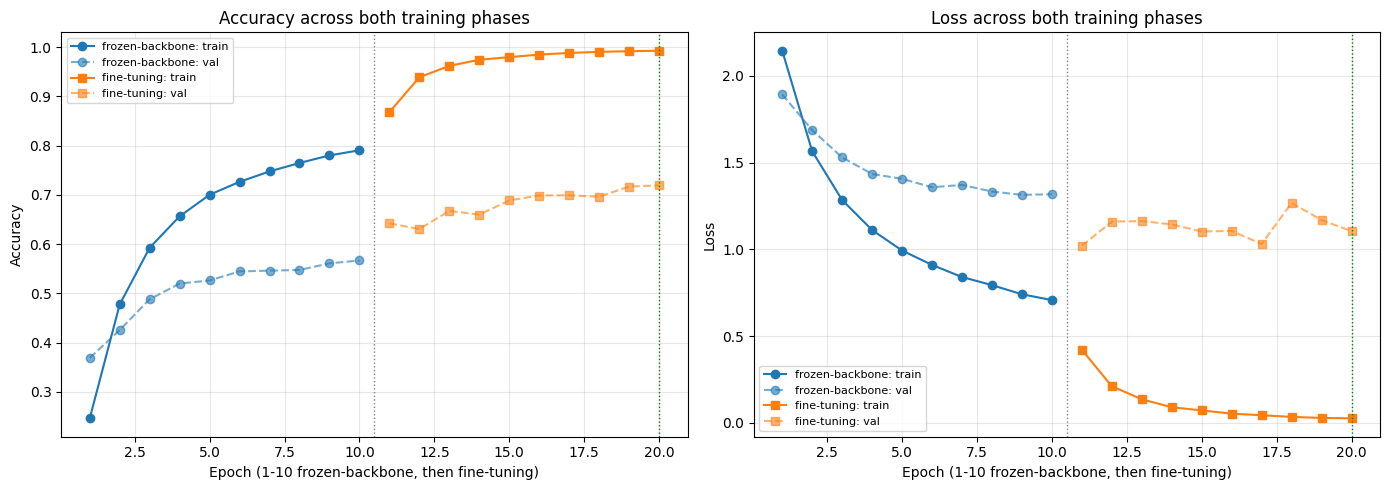

Saved training curves to: D:\MSC_PROJECT\results\figures\mobilenetv2_lowlight_training_curves.png
Fine-tuning restored epoch 10 (val_accuracy=0.7193) after early stopping.


In [16]:
import re


def parse_training_log(path):
    text = Path(path).read_text()
    epochs = [int(e) for e in re.findall(r"Epoch (\d+)/\d+", text)]
    rows = re.findall(
        r"loss: ([\d.]+) - accuracy: ([\d.]+) - val_loss: ([\d.]+) - val_accuracy: ([\d.]+)", text
    )
    return pd.DataFrame({
        "epoch": epochs,
        "loss": [float(r[0]) for r in rows],
        "accuracy": [float(r[1]) for r in rows],
        "val_loss": [float(r[2]) for r in rows],
        "val_accuracy": [float(r[3]) for r in rows],
    })


frozen_history = parse_training_log(EXPERIMENT_DIR / "training_log_frozen_backbone.txt")
finetune_history = parse_training_log(EXPERIMENT_DIR / "training_log_finetuned.txt")
finetune_best_epoch = int(finetune_history.loc[finetune_history["val_accuracy"].idxmax(), "epoch"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in [(axes[0], "accuracy", "Accuracy"), (axes[1], "loss", "Loss")]:
    ax.plot(frozen_history["epoch"], frozen_history[metric], "o-", color="tab:blue", label="frozen-backbone: train")
    ax.plot(frozen_history["epoch"], frozen_history[f"val_{metric}"], "o--", color="tab:blue", alpha=0.6, label="frozen-backbone: val")
    ft_epochs = frozen_history["epoch"].max() + finetune_history["epoch"]
    ax.plot(ft_epochs, finetune_history[metric], "s-", color="tab:orange", label="fine-tuning: train")
    ax.plot(ft_epochs, finetune_history[f"val_{metric}"], "s--", color="tab:orange", alpha=0.6, label="fine-tuning: val")
    ax.axvline(frozen_history["epoch"].max() + 0.5, color="gray", linestyle=":", linewidth=1)
    ax.axvline(frozen_history["epoch"].max() + finetune_best_epoch, color="green", linestyle=":", linewidth=1)
    ax.set_xlabel(f"Epoch (1-{frozen_history['epoch'].max()} frozen-backbone, then fine-tuning)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} across both training phases")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
curves_path = FIGURES_DIR / "mobilenetv2_lowlight_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print("Saved training curves to:", curves_path)
print(f"Fine-tuning restored epoch {finetune_best_epoch} (val_accuracy={finetune_history['val_accuracy'].max():.4f}) after early stopping.")

## Confusion matrices: baseline vs. frozen-backbone vs. fine-tuned

Three panels — baseline collapse-to-two-classes is easier to see as a picture. All three computed on the same merged test set for a fair comparison.

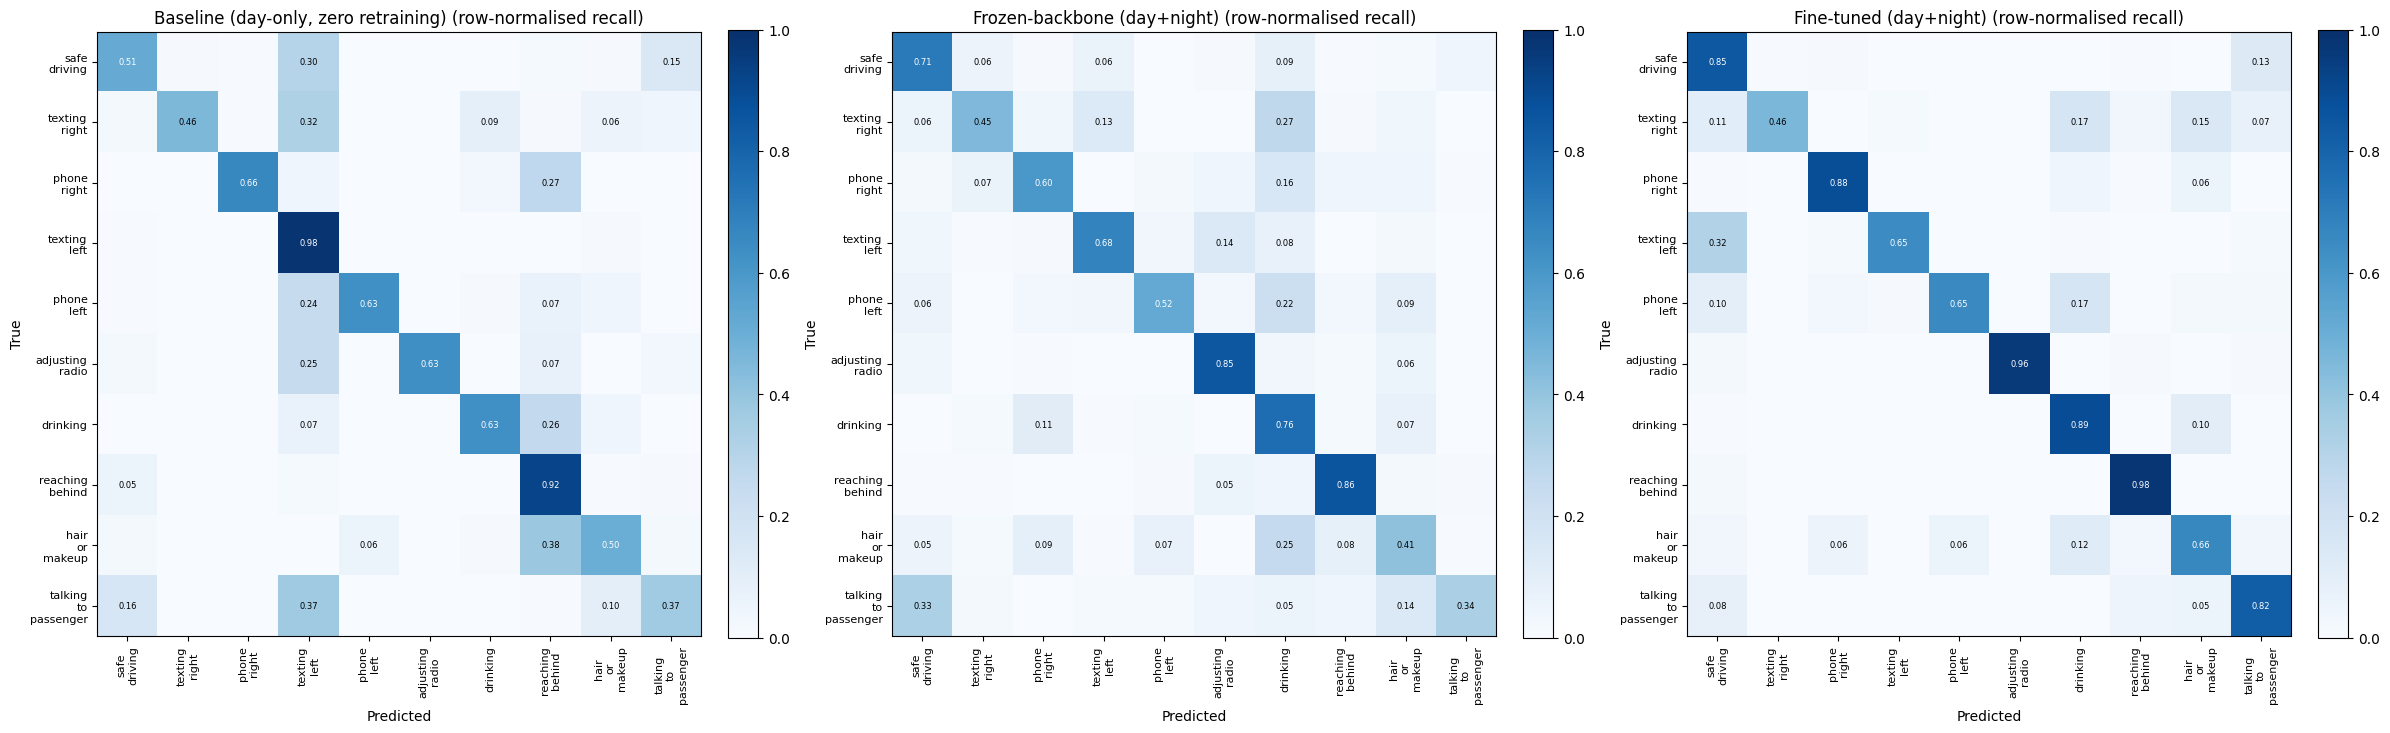

Saved confusion matrices to: D:\MSC_PROJECT\results\figures\mobilenetv2_lowlight_confusion_matrices.png


In [17]:
def get_predictions(model_obj, dataset):
    y_t = np.concatenate([labels.numpy() for _, labels in dataset], axis=0)
    y_p = np.argmax(model_obj.predict(dataset, verbose=0), axis=1)
    return y_t, y_p


y_true_baseline_mixed, y_pred_baseline_mixed = get_predictions(baseline_model, test_ds)
y_true_frozen, y_pred_frozen = get_predictions(frozen_model, test_ds)
y_true_finetuned, y_pred_finetuned = get_predictions(best_finetuned_model, test_ds)

cm_baseline = confusion_matrix(y_true_baseline_mixed, y_pred_baseline_mixed, normalize="true")
cm_frozen = confusion_matrix(y_true_frozen, y_pred_frozen, normalize="true")
cm_finetuned = confusion_matrix(y_true_finetuned, y_pred_finetuned, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
short_labels = [n.replace("_", "\n") for n in LABEL_NAMES]

for ax, cm, title in [
    (axes[0], cm_baseline, "Baseline (day-only, zero retraining)"),
    (axes[1], cm_frozen, "Frozen-backbone (day+night)"),
    (axes[2], cm_finetuned, "Fine-tuned (day+night)"),
]:
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(short_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title} (row-normalised recall)")
    for i in range(10):
        for j in range(10):
            val = cm[i, j]
            if val >= 0.05:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                         fontsize=6, color="white" if val > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
cm_fig_path = FIGURES_DIR / "mobilenetv2_lowlight_confusion_matrices.png"
plt.savefig(cm_fig_path, dpi=150)
plt.show()
print("Saved confusion matrices to:", cm_fig_path)

## Qualitative check: random real test images

Visual sanity check, same pattern as notebook 09. 12 random images (mix of State Farm day and `low_light_dd` night), fine-tuned model predictions, green title = correct, red = wrong.

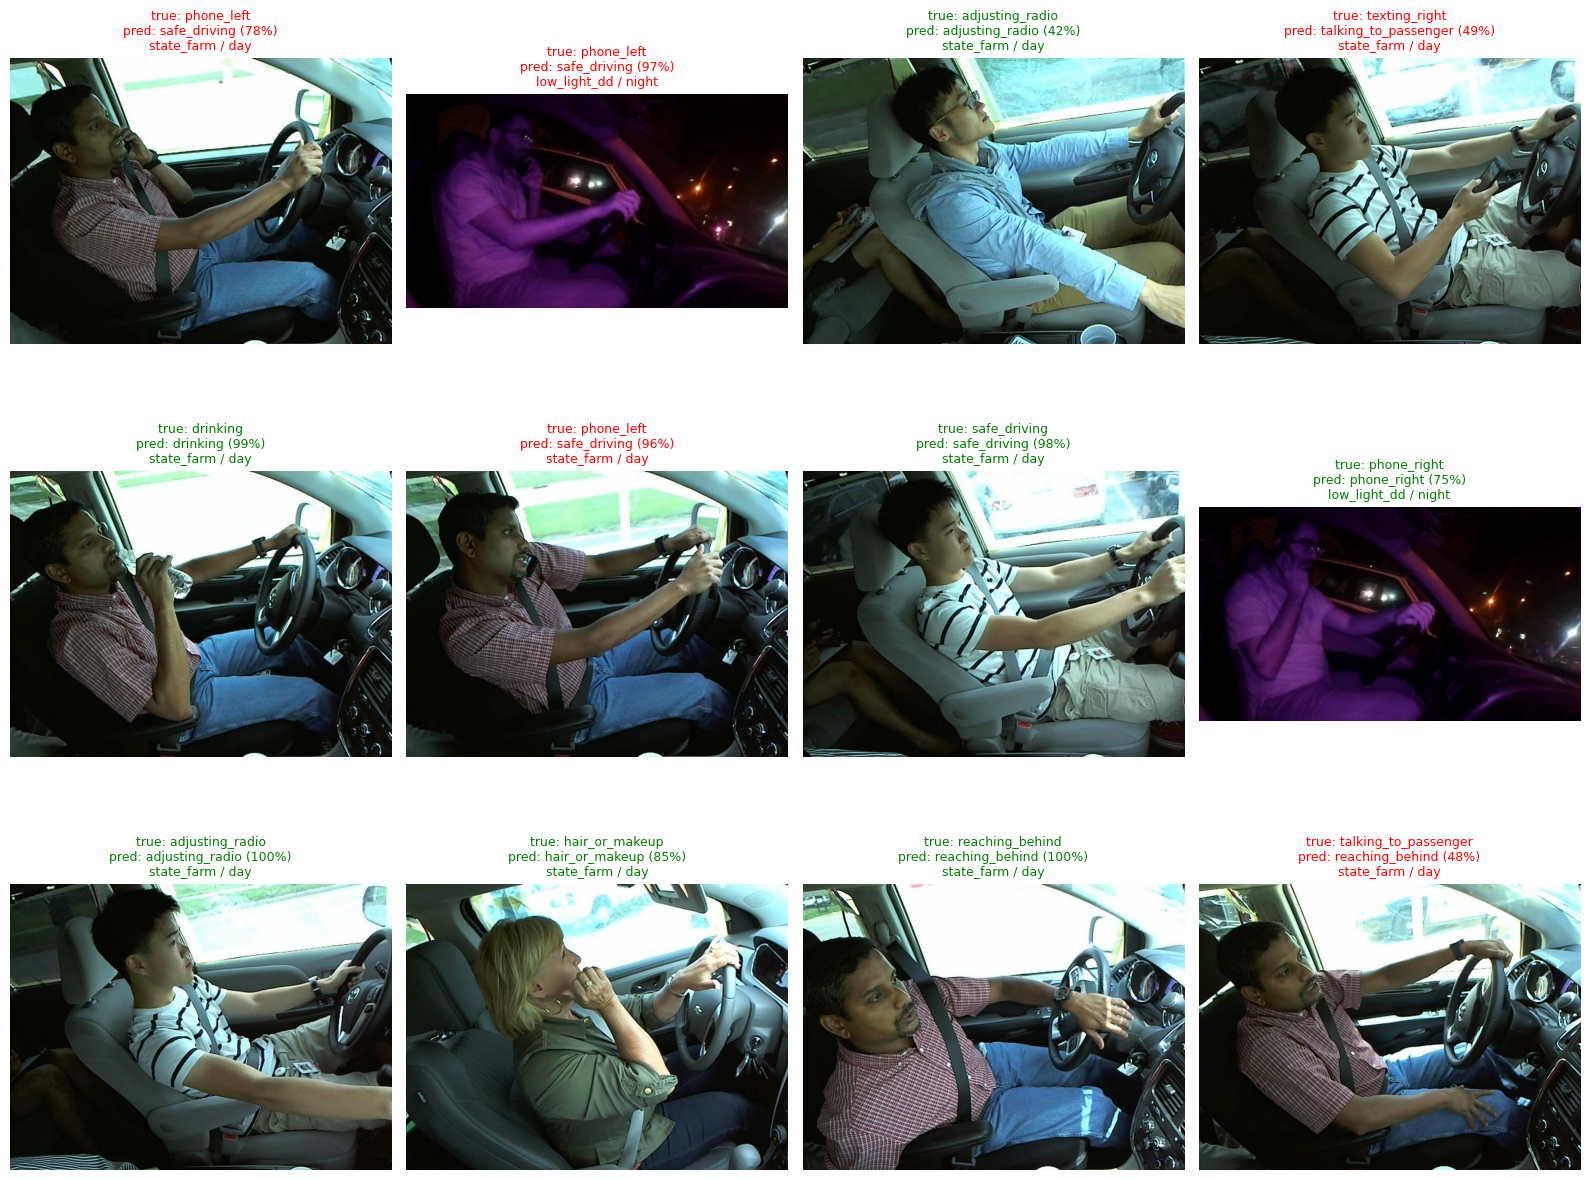

Saved qualitative sample grid to: D:\MSC_PROJECT\results\figures\mobilenetv2_lowlight_qualitative_samples.png


In [18]:
qual_test_df = test_df.sample(n=12, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 13))

for ax, (_, row) in zip(axes.flatten(), qual_test_df.iterrows()):
    raw_bytes = tf.io.read_file(row["image_path"])
    img = tf.image.decode_jpeg(raw_bytes, channels=3)
    img_resized = tf.image.resize(img, IMG_SIZE)
    img_batch = tf.expand_dims(tf.cast(img_resized, tf.float32), axis=0)

    probs = best_finetuned_model.predict(img_batch, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    pred_name = LABEL_NAMES[pred_id]
    true_name = row["label_name"]
    confidence = probs[pred_id]

    ax.imshow(img.numpy())
    correct = pred_name == true_name
    ax.set_title(
        f"true: {true_name}\npred: {pred_name} ({confidence:.0%})\n{row['dataset_name']} / {row['lighting']}",
        fontsize=9, color=("green" if correct else "red"),
    )
    ax.axis("off")

plt.tight_layout()
qual_fig_path = FIGURES_DIR / "mobilenetv2_lowlight_qualitative_samples.png"
plt.savefig(qual_fig_path, dpi=150)
plt.show()

print("Saved qualitative sample grid to:", qual_fig_path)

## Overall summary

- Domain gap is real and severe: day-only model collapses to 19.53% on night footage (from 84.67% on day), guessing only 2 of 10 classes.
- Mostly fixable with real merged data: frozen-backbone gets 62.30% mixed; fine-tuning last 30 layers gets **77.91% mixed / 71.13% night**, using only 6,750 real night images (9 drivers).
- Dataset turned out to be mixed day/night, not uniformly night (9 of 70 drivers genuinely night, found via brightness audit in notebook 08 Adapter 5) — real night data is a smaller 6,750-image subset, not the ~52,000 originally assumed.
- Recovering night performance costs a bit of day performance: fine-tuned day accuracy (81.21%) still short of the original 84.67%.
- Label-quality caveat on 4 classes (`texting_right/left`, `phone_right/left`): hand-side mapping in the low-light dataset couldn't be visually verified (notebook 08, Adapter 5). Likely connected to `texting_right`'s odd high-precision/low-recall behaviour. Doesn't affect the main day/night finding.

Summary for supervisor: day-only model fails badly under a real lighting shift; fine-tuning on real night data (even a small amount) recovers most of it; that recovery costs some day-domain accuracy. All numbers from real executed runs. The mixed day/night composition of the dataset was a genuine mid-project discovery, not assumed from the name.